## Imports

In [1]:
from utils.data_prepocessing import _ensure_monthly_index_and_align_exog, plot_forecaster_feature_importance
from utils.constants import (
CATEGORY_MAP,
CAT_MAP_ENCODING,
CATEGORY_MAP_CHEMICALS,
CATEGORY_MAP_CHEMICALS_ENCODING,
BEST_PREDICTORS_FOR_INDEX,
BEST_PREDICTORS_FOR_INDEX_CHEMICALS,
)
from utils.utils import (
    transform_and_plot_trend_for_cat,
    get_best_result_for_runs,
    plot_best_mape_predictors,
    aggregate_metrics_result,
    extrapolate_results,
    plot_known_feature_value,
    extrapolate_results_to_single_ts
)
from utils.cluster_forecast import ClusterForecaster
from itertools import combinations
from typing import Type, Literal, Any
from darts import TimeSeries
import pandas as pd
import os

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


---
## Data prepocessing

In [2]:
directory = "Data/"  # set directory path
d = {}
formed = {}

for i, entry in enumerate(os.scandir(directory)):  
    if entry.is_file() and entry.name.endswith('.xlsx'):  # check if it's a file
        # print(entry.name)
        d[entry.name] = pd.read_excel(f"{directory}{entry.name}")
    elif entry.is_file() and entry.name.endswith('.csv'):
        formed[entry.name] = pd.read_csv(f"{directory}{entry.name}")

global_macros = d["global_macro.xlsx"]
apk_nona = formed["apk_nona.csv"]

chemicals_nona = formed["chemicals_nona.csv"]
chemicals_nona["Date"] = pd.to_datetime(chemicals_nona["Date"])
chemicals_nona = chemicals_nona.set_index('Date')

global_macros = global_macros.drop(columns=["Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),  .1"])

apk_nona["Date"] = apk_nona["Unnamed: 0"]
apk_nona["Date"] = pd.to_datetime(apk_nona["Date"])

global_macros = global_macros.iloc[3:][::-1].reset_index(drop=True)
global_macros = global_macros.drop(columns=["Date"])
global_macros.index = apk_nona["Date"]

apk_nona = apk_nona.set_index('Date')


assert global_macros.shape[0] == apk_nona.shape[0]


apk_nona_en, global_macros_en = _ensure_monthly_index_and_align_exog(apk_nona, global_macros)
chemicals_nona_en, global_macros_en_chemicals = _ensure_monthly_index_and_align_exog(chemicals_nona[chemicals_nona.index<=global_macros.index.max()],
                                                                                     global_macros[global_macros.index>=chemicals_nona.index.min()])
global_macros_en.columns = list(map(lambda x: " ".join(x.split()), list(global_macros_en.columns)))  # убираем табы

apk_nona_en_rol = transform_and_plot_trend_for_cat(apk_nona_en, 12, norm_method="index", plot_graphics=False)
chemicals_nona_en_rol = transform_and_plot_trend_for_cat(chemicals_nona_en, 12, norm_method="index", features_to_cat=CATEGORY_MAP_CHEMICALS, plot_graphics=False)

macro_data = global_macros_en[global_macros_en.index >= apk_nona_en_rol.dropna().index[0]]

---
## Global parameters setting

In [7]:
PREDICTION_HORIZON_APK = 12
NAIVE_PREDICTOR_WINDOW_LENGTH_APK = 12
PREDICTION_HORIZON_CHEMICALS = 12
NAIVE_PREDICTOR_WINDOW_LENGTH_CHEMICALS = 12
PREDICTOR_LAG_APK = 12
PREDICTOR_LAG_CHEMICALS = 12
FUTURE_DATE_APK = apk_nona_en_rol.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON_APK)
BACKTEST_DATE_APK = apk_nona_en_rol.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON_APK*2)
IS_BACKTEST: bool = True
BACKTEST_DATE_CHEMICALS = chemicals_nona_en_rol.index[-1] - pd.DateOffset(months=PREDICTION_HORIZON_CHEMICALS*2)
## Parameters with known future values
FUTURE_FORECASTER_TS_NAME = "Ключевая ставка, годовых"
FUTURE_FORECASTER_TS_VALUES = [22.2]*(PREDICTION_HORIZON_APK)
if not FUTURE_FORECASTER_TS_VALUES:
    for _ in range(max(PREDICTION_HORIZON_APK, PREDICTION_HORIZON_CHEMICALS)):
        tmp = input()
        FUTURE_FORECASTER_TS_VALUES.append(float(tmp))

## Directories to save naive results
NAIVE_PREDICTOR_RESULT_PATH_APK = f"darts_result_tables_naive_{PREDICTION_HORIZON_APK}"
NAIVE_PREDICTOR_RESULT_PATH_CHEMICALS = f"darts_result_tables_naive_chemicals_{NAIVE_PREDICTOR_WINDOW_LENGTH_CHEMICALS}"
## Directories to save naive results

TARGET_COL_SUFFIX = "_sum"
MODEL_NAME_FOR_FORECASTER: Literal["tftmodel", "nbeats", "naiveseasonal", "naivedrift", "naivemean", "naivemovingaverage"] = "nbeats"
USE_FUTURE_COV = MODEL_NAME_FOR_FORECASTER in ("tftmodel")
TS_TO_PREDICT_APK = "Кукуруза"
TS_TO_PREDICT_CHEMICALS = "Карбамид (FOB Южный)"

train_end = BACKTEST_DATE_APK
past_idx = pd.date_range(start=train_end + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON_APK,
                           freq="MS")
future_idx = pd.date_range(start=past_idx[-1] + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON_APK,
                           freq="MS")

---
## Known TS future

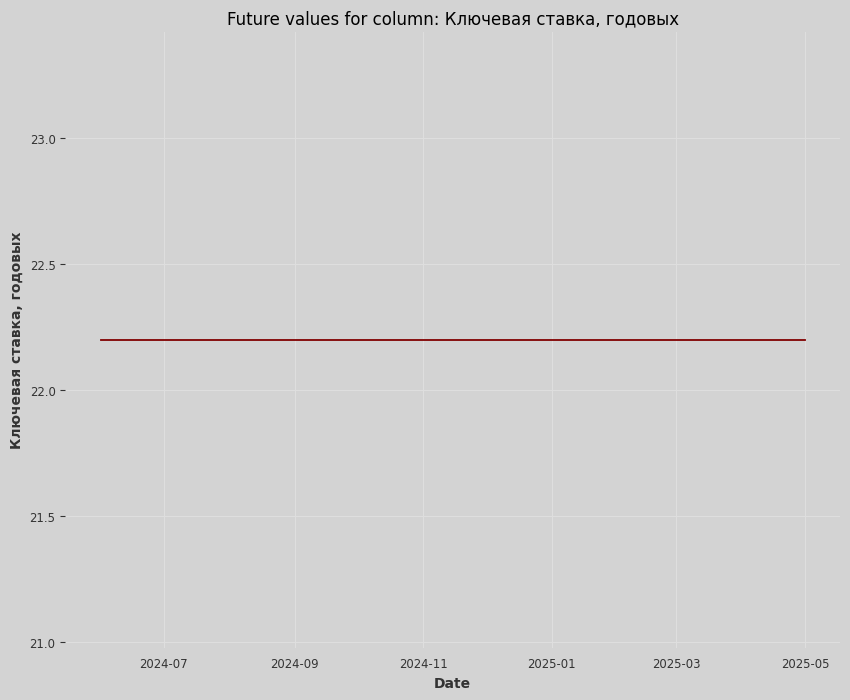

In [8]:
plot_known_feature_value(FUTURE_FORECASTER_TS_VALUES,
                         FUTURE_FORECASTER_TS_NAME,
                         pd.date_range(start=FUTURE_DATE_APK + pd.DateOffset(months=1),
                           periods=PREDICTION_HORIZON_APK,
                           freq="MS"))

---
## APK

### Forecasting clusers

In [9]:
def train_model_and_eval_res(df: pd.DataFrame,
                             macro_data: pd.DataFrame,
                             past_idx = past_idx,
                             future_idx = future_idx,
                             category_map: dict = CATEGORY_MAP,
                             best_predictors_for_idx: dict = BEST_PREDICTORS_FOR_INDEX,
                             target_col_suffix:str = TARGET_COL_SUFFIX,
                             future_forecaster_ts_name:str = FUTURE_FORECASTER_TS_NAME,
                             future_forecaster_ts_values: str = FUTURE_FORECASTER_TS_VALUES,
                             model_name: str = MODEL_NAME_FOR_FORECASTER,
                             use_future_macro: bool = USE_FUTURE_COV,
                             prediction_horizon: int = PREDICTION_HORIZON_APK,
                             dir_to_save_plots: str = f"darts_result_pairs_{MODEL_NAME_FOR_FORECASTER}",
                             dir_to_save_tables: str = f"darts_result_tables_pairs_{MODEL_NAME_FOR_FORECASTER}"
                            ):
    all_clusters = sorted(set(category_map.values()))
    forecasts_for_cluster: dict[str, Type[TimeSeries]] = {}
    forecasters_for_cluster: dict[str, Type[ClusterForecaster]] = {}
    past_data_for_train = df[df.index<=past_idx[-1]]
    macro_data_for_train = macro_data[macro_data.index<=past_idx[-1]]
    for target_cat in all_clusters:
        predictors_lst:list[str] = best_predictors_for_idx.get(target_cat)
    
        forecaster = ClusterForecaster(
            cluster_data=past_data_for_train,
            macro_data=macro_data_for_train,
            category_map=category_map,
            freq="M",
            target_col_suffix=target_col_suffix,
            dir_to_save_plots=dir_to_save_plots,
            dir_to_save_tables=dir_to_save_tables,
            future_macro_col=future_forecaster_ts_name
        )
        forecaster.train(target_cat, predictors_lst, model_type=MODEL_NAME_FOR_FORECASTER, use_future_macro=use_future_macro)
        cov_past = pd.DataFrame(index=past_idx)
        cov_past = pd.concat([cov_past, macro_data[macro_data.index < future_idx[0]]], axis=1)
        if predictors_lst:
            for additional_cluster in predictors_lst:
                all_add = df[f"{additional_cluster}{target_col_suffix}"].shift(1)
                cov_past[f"{additional_cluster}_lag1"] = all_add.reindex(past_idx)
        cov_past = cov_past.fillna(method="bfill").fillna(method="ffill")
        if IS_BACKTEST:
            cov_future = pd.concat([pd.DataFrame(macro_data[future_forecaster_ts_name][past_idx]),
               pd.DataFrame(macro_data[future_forecaster_ts_name][future_idx])])
        else:
            cov_future = pd.concat([pd.DataFrame(macro_data[future_forecaster_ts_name][past_idx]),
                                    pd.DataFrame(future_forecaster_ts_values,
                                               index=future_idx,
                                               columns=[future_forecaster_ts_name])]
                                  )        
        preds = forecaster.forecast(prediction_horizon,
                            cov_past,
                            cov_future if use_future_macro else None)
        if MODEL_NAME_FOR_FORECASTER in ("tftmodel"):
            preds *= 10
        forecasters_for_cluster[target_cat] = forecaster
        forecasts_for_cluster[target_cat] = preds
        target_s = df[df.index >= pd.to_datetime(future_idx[0])][f"{target_cat}_sum"]
        pred_ts, actual_ts, metrics = forecaster.plot_and_return_data_backtest(TimeSeries.from_series(target_s),
                                                                               preds,
                                                                               target_cat,
                                                                               future_idx,
                                                                               predictors_lst)

C:\Users\omirz\Desktop\Sber_conditional\Sber-Conditional\utils\cluster_forecast.py:144: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_df = cov_df.fillna(method="bfill").fillna(method="ffill")
C:\Users\omirz\Desktop\Sber_conditional\Sber-Conditional\utils\cluster_forecast.py:145: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_cov_df = future_cov_df.fillna(method="bfill").fillna(method="ffill")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Ti Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/g

Epoch 99: 100%|████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  6.84it/s, train_loss=17.70]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  6.76it/s, train_loss=17.70]


C:\Users\omirz\AppData\Local\Temp\ipykernel_37812\2400522554.py:41: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_past = cov_past.fillna(method="bfill").fillna(method="ffill")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Epoch 99: 100%|████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  7.16it/s, train_loss=30.80]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  6.87it/s, train_loss=30.80]


C:\Users\omirz\AppData\Local\Temp\ipykernel_37812\2400522554.py:41: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_past = cov_past.fillna(method="bfill").fillna(method="ffill")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|███████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 34.69it/s]


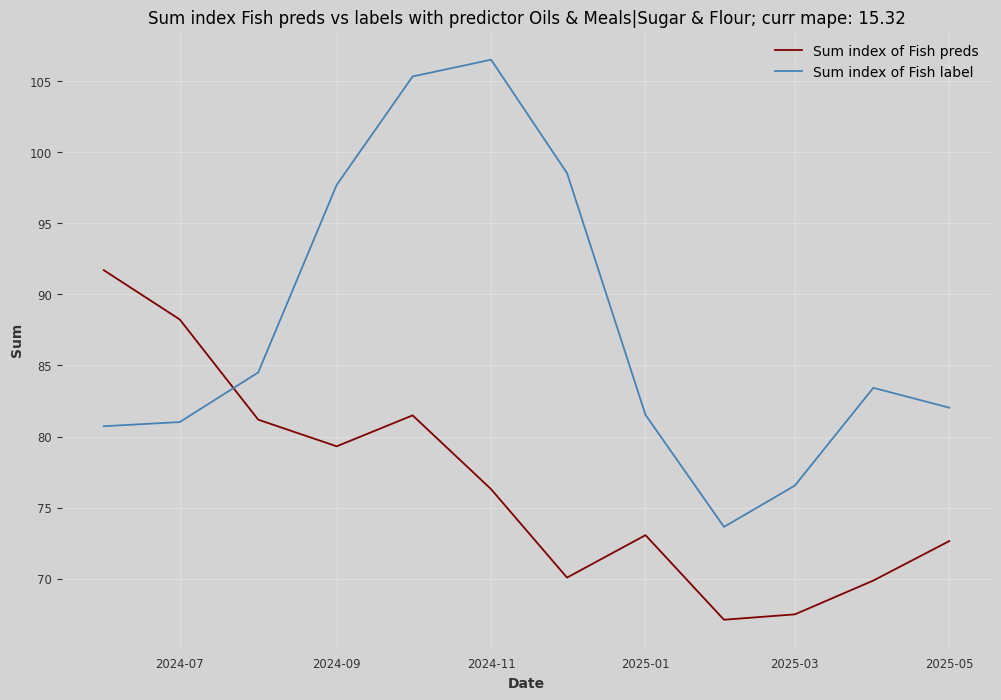

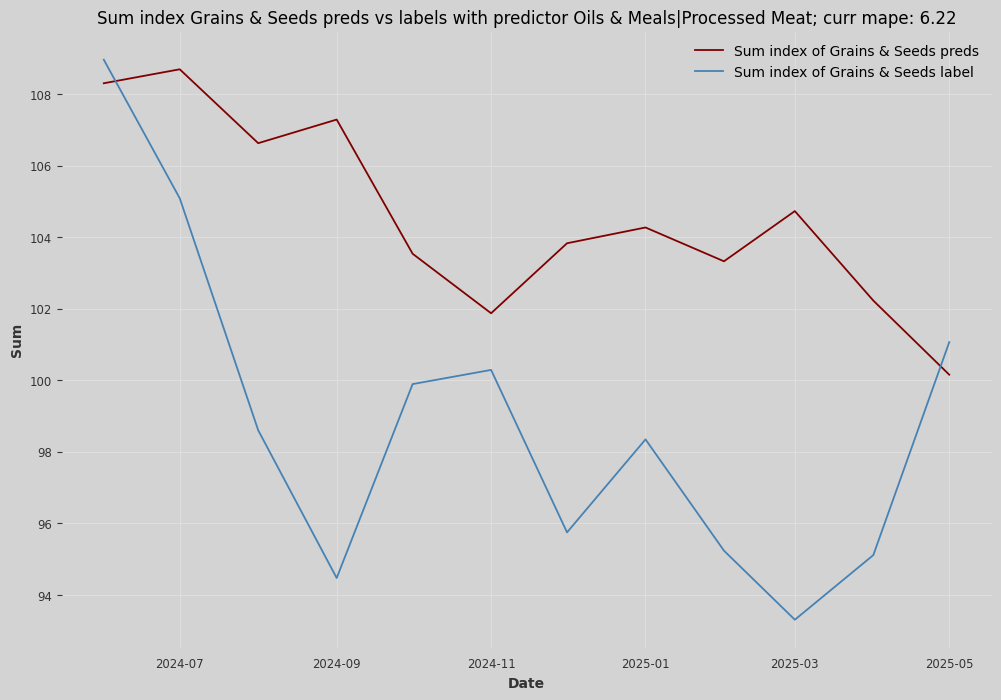

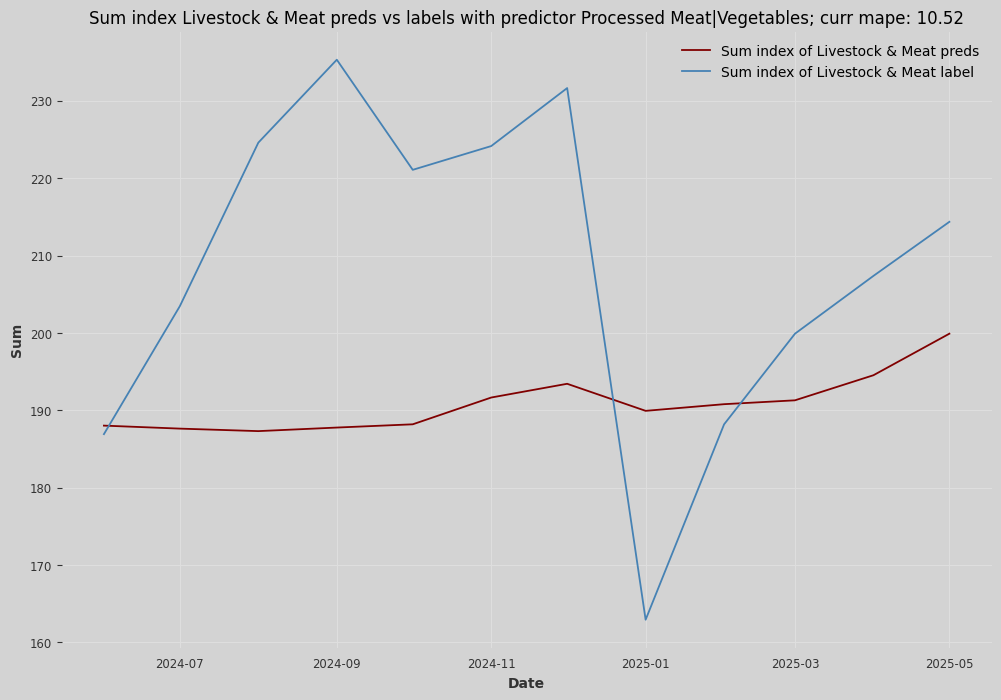

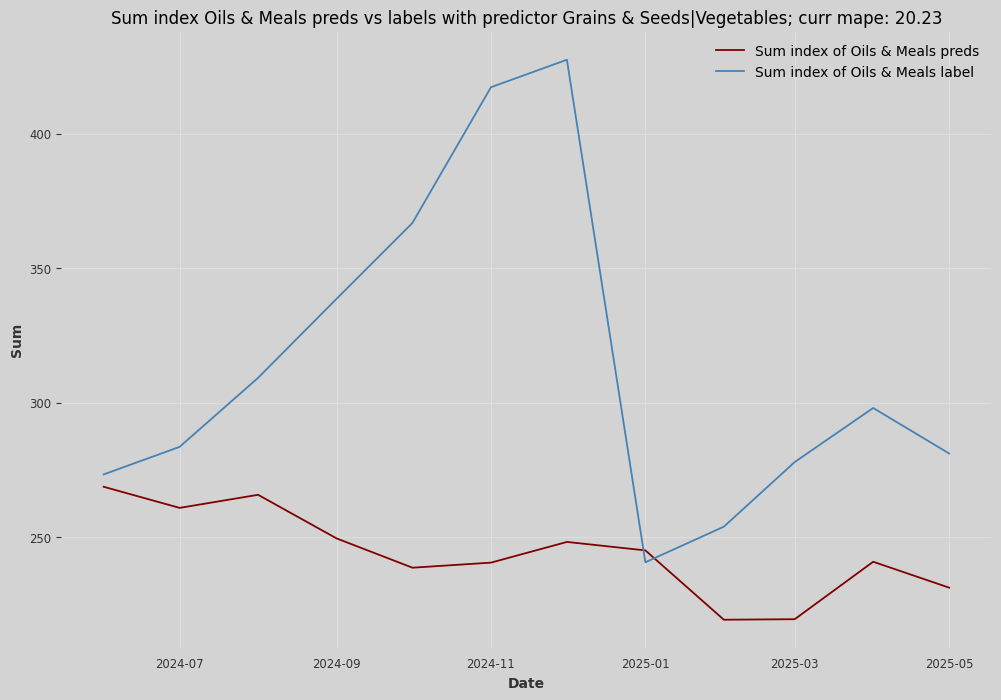

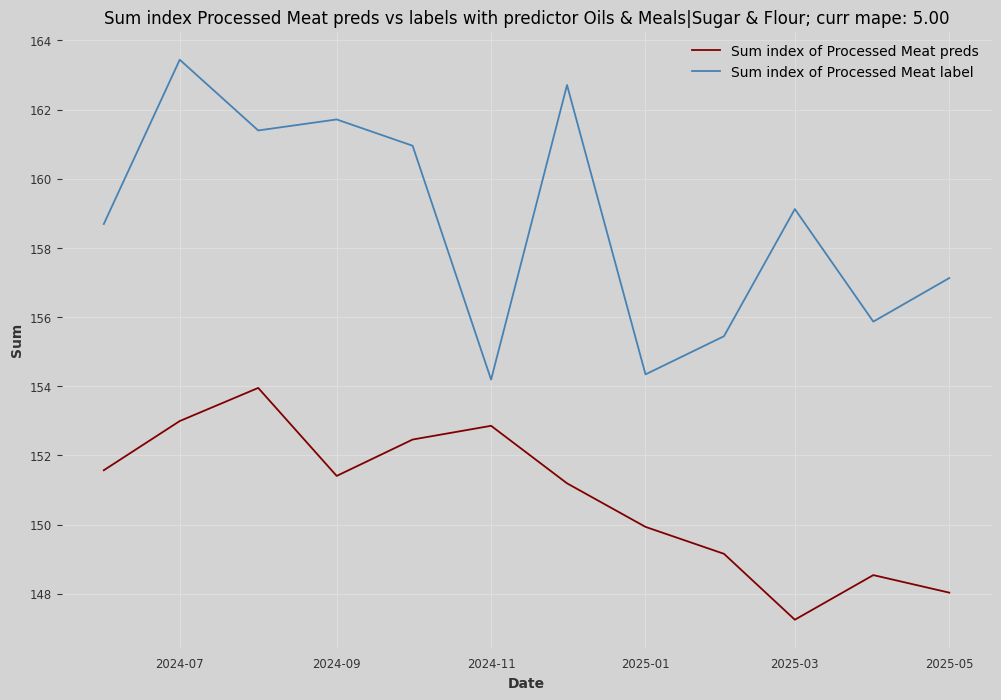

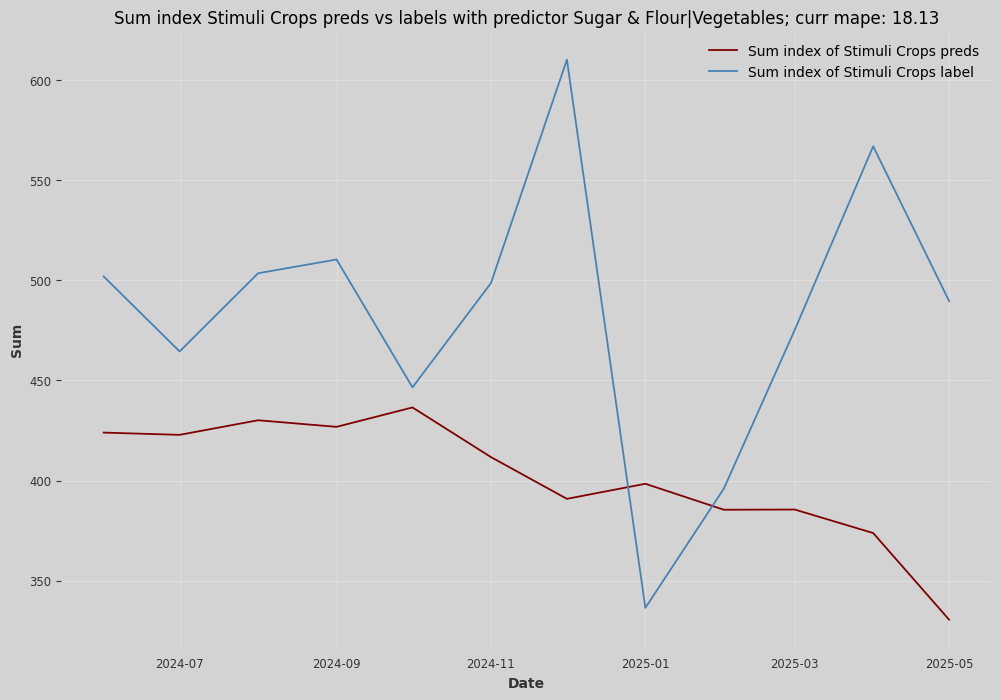

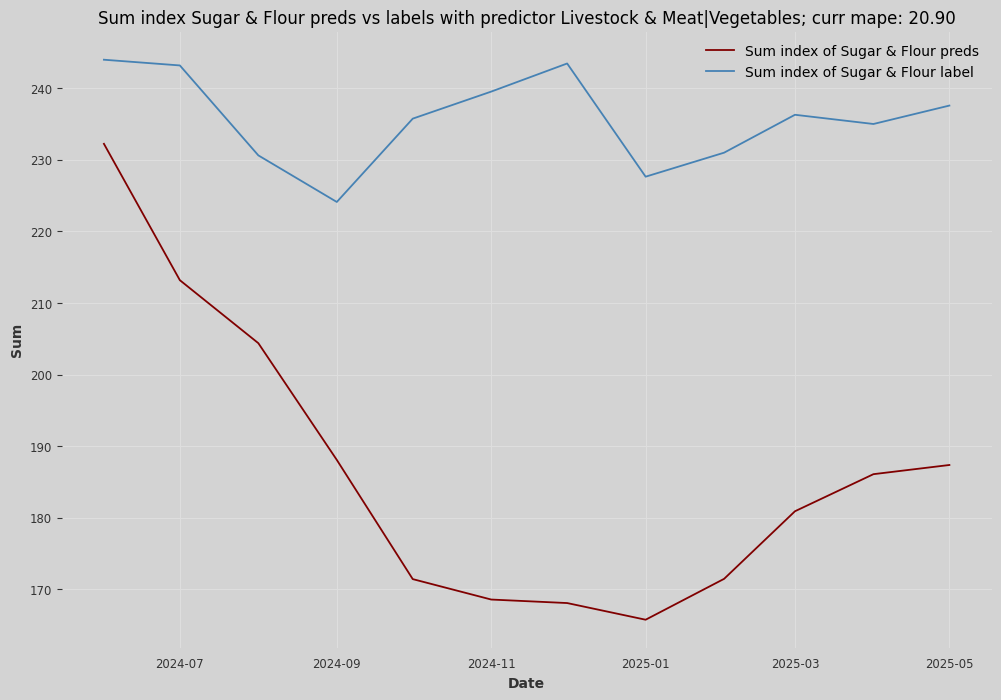

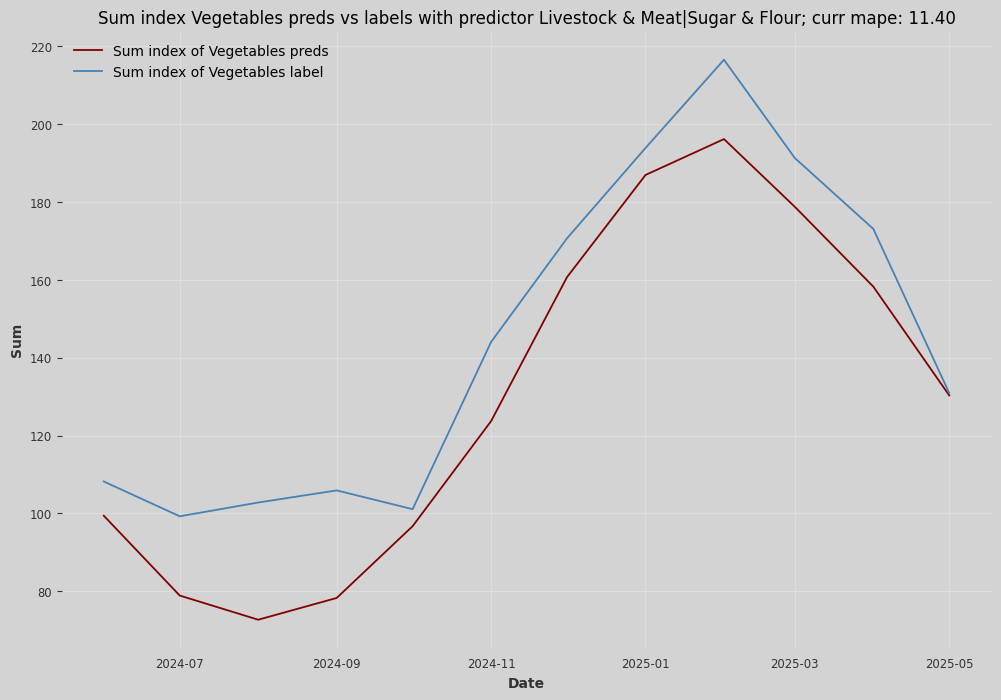

In [10]:
train_model_and_eval_res(apk_nona_en_rol.dropna(),
                         macro_data,
                         past_idx = past_idx,
                         future_idx = future_idx,
                         category_map = CATEGORY_MAP,
                         best_predictors_for_idx = BEST_PREDICTORS_FOR_INDEX,
                         target_col_suffix = TARGET_COL_SUFFIX,
                         future_forecaster_ts_name = FUTURE_FORECASTER_TS_NAME,
                         future_forecaster_ts_values = FUTURE_FORECASTER_TS_VALUES,
                         model_name = MODEL_NAME_FOR_FORECASTER,
                         use_future_macro = USE_FUTURE_COV,
                         prediction_horizon = PREDICTION_HORIZON_APK,
                         dir_to_save_plots = f"darts_result_pairs_{MODEL_NAME_FOR_FORECASTER}",
                         dir_to_save_tables = f"darts_result_tables_pairs_{MODEL_NAME_FOR_FORECASTER}"
)

C:\Users\omirz\Desktop\Sber_conditional\Sber-Conditional\utils\cluster_forecast.py:144: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_df = cov_df.fillna(method="bfill").fillna(method="ffill")
C:\Users\omirz\Desktop\Sber_conditional\Sber-Conditional\utils\cluster_forecast.py:145: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  future_cov_df = future_cov_df.fillna(method="bfill").fillna(method="ffill")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   |

Epoch 99: 100%|████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  7.48it/s, train_loss=250.0]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  7.39it/s, train_loss=250.0]


C:\Users\omirz\AppData\Local\Temp\ipykernel_37812\2400522554.py:41: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_past = cov_past.fillna(method="bfill").fillna(method="ffill")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Epoch 99: 100%|██████████████████████████████████████████████████████| 3/3 [00:00<00:00,  7.92it/s, train_loss=3.32e+3]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████████████████████████████████████████████████| 3/3 [00:00<00:00,  7.59it/s, train_loss=3.32e+3]


C:\Users\omirz\AppData\Local\Temp\ipykernel_37812\2400522554.py:41: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  cov_past = cov_past.fillna(method="bfill").fillna(method="ffill")
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|███████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 36.40it/s]


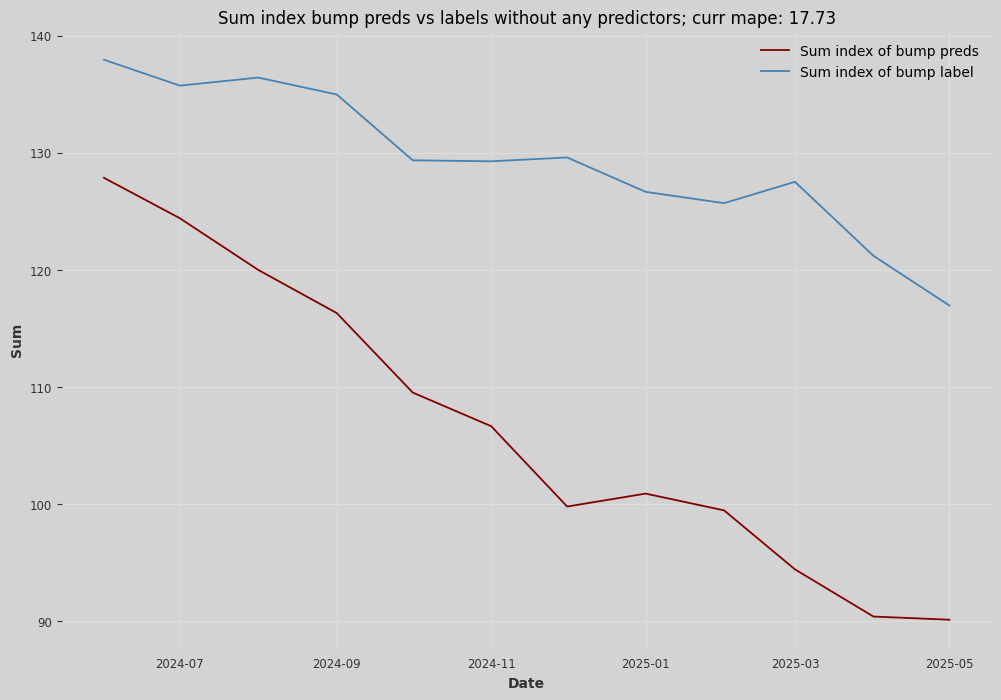

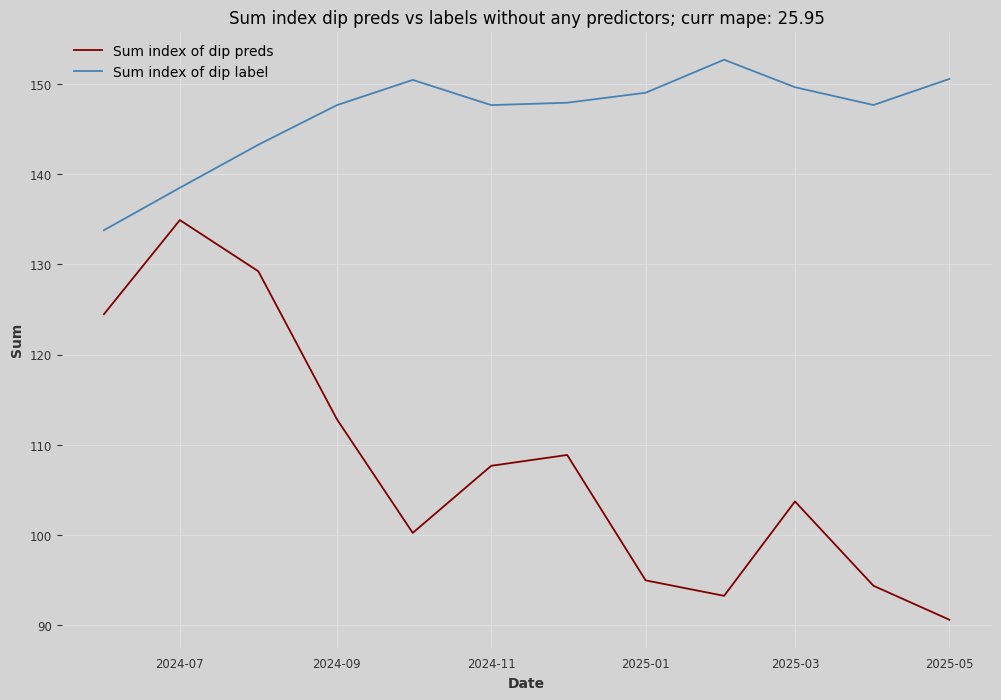

In [11]:
train_model_and_eval_res(chemicals_nona_en_rol.dropna(),
                         macro_data,
                         past_idx = past_idx,
                         future_idx = future_idx,
                         category_map = CATEGORY_MAP_CHEMICALS,
                         best_predictors_for_idx = BEST_PREDICTORS_FOR_INDEX_CHEMICALS,
                         target_col_suffix = TARGET_COL_SUFFIX,
                         future_forecaster_ts_name = FUTURE_FORECASTER_TS_NAME,
                         future_forecaster_ts_values = FUTURE_FORECASTER_TS_VALUES,
                         model_name = MODEL_NAME_FOR_FORECASTER,
                         use_future_macro = USE_FUTURE_COV,
                         prediction_horizon = PREDICTION_HORIZON_APK,
                         dir_to_save_plots = f"darts_result_pairs_{MODEL_NAME_FOR_FORECASTER}",
                         dir_to_save_tables = f"darts_result_tables_pairs_{MODEL_NAME_FOR_FORECASTER}"
)

### Forecasting specific TS

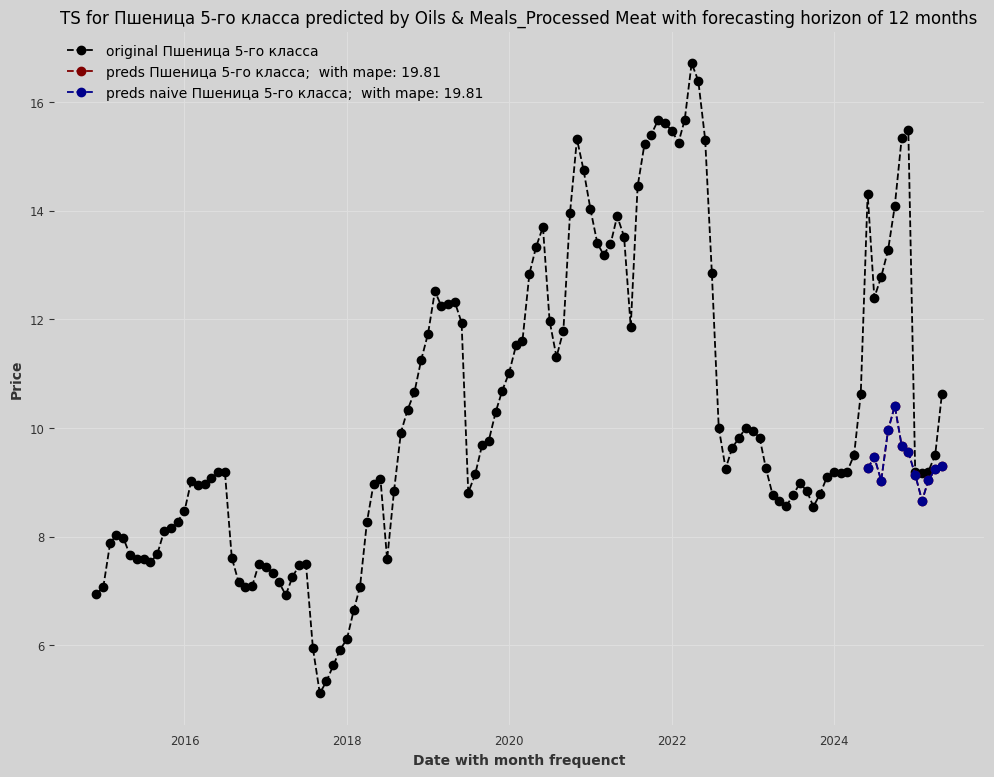

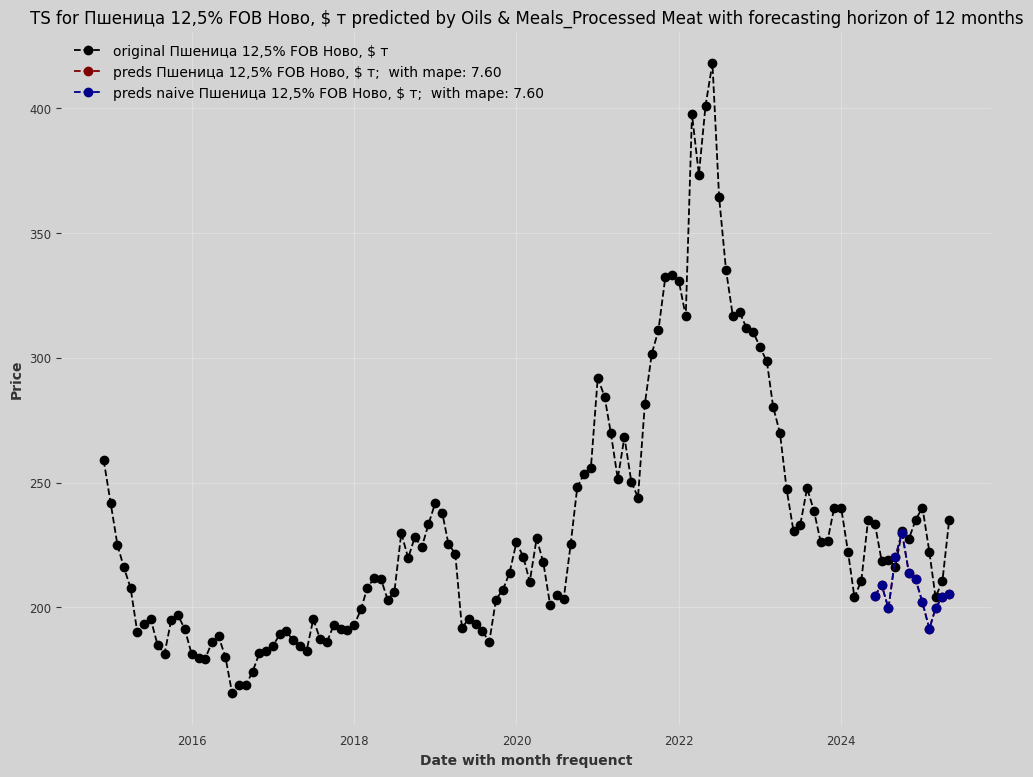

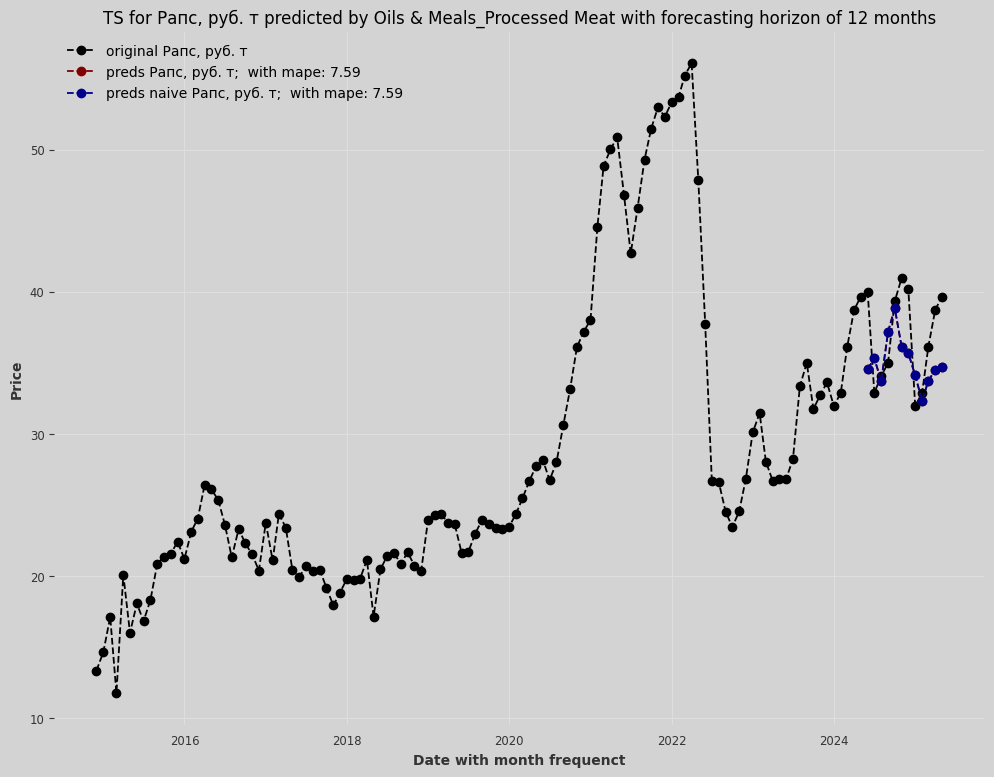

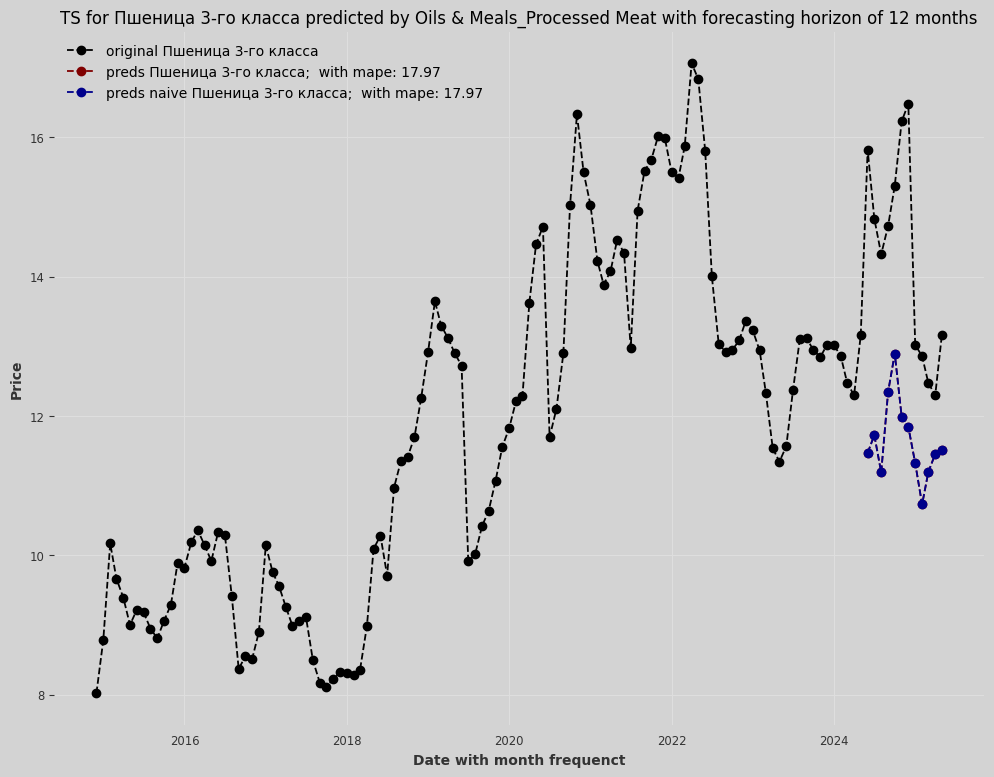

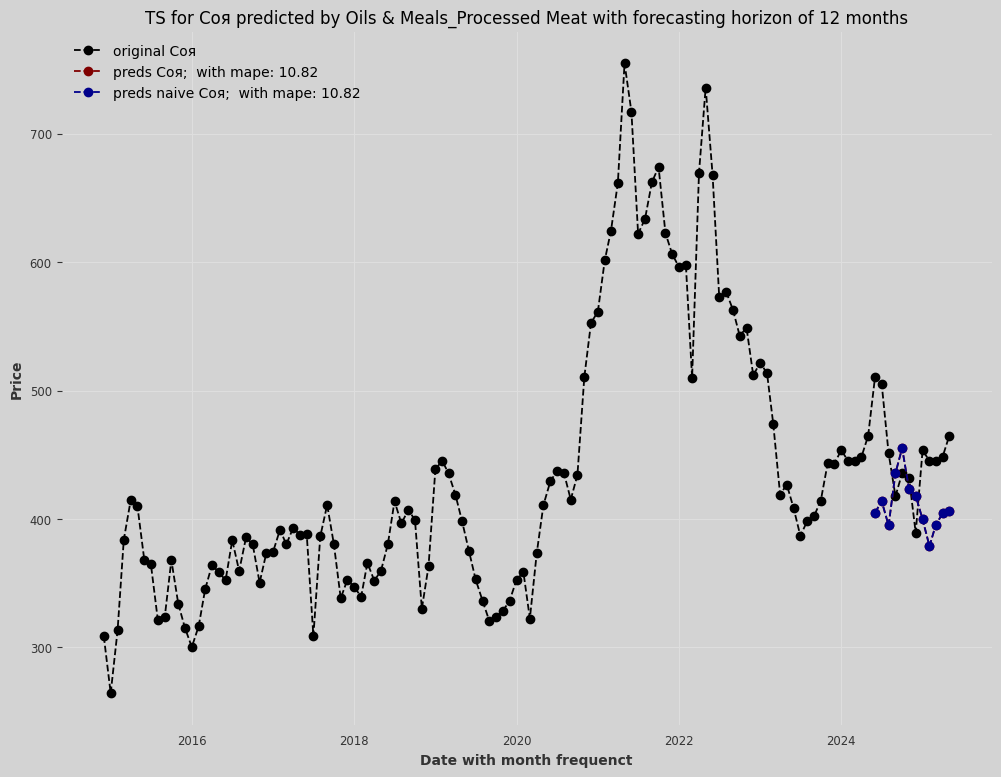

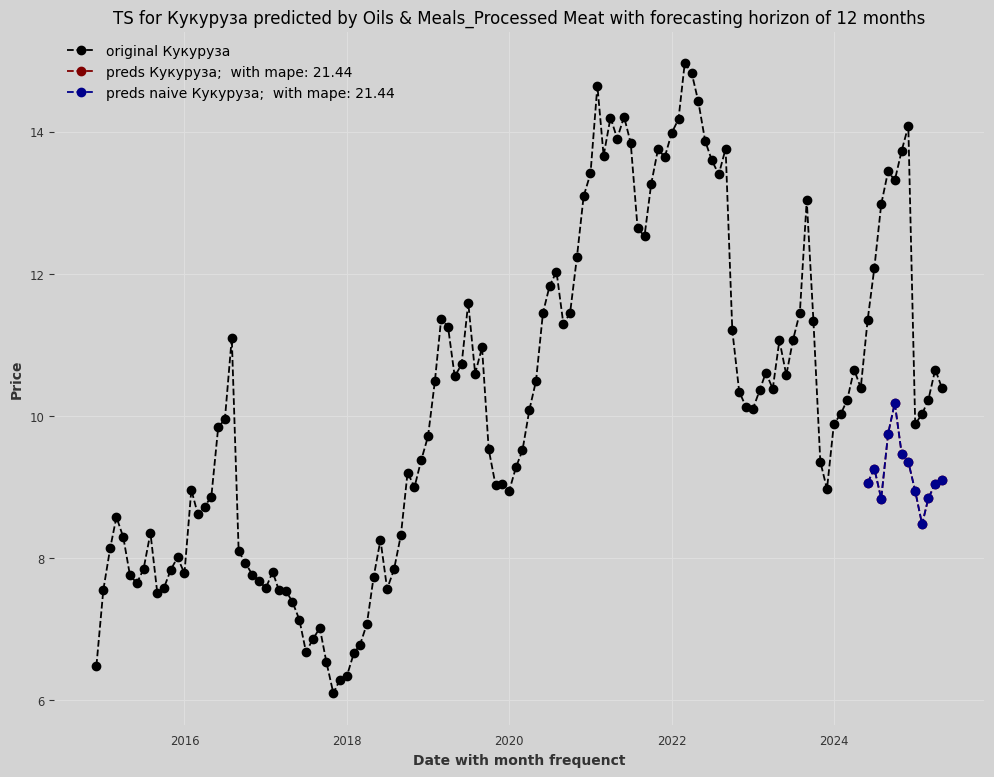

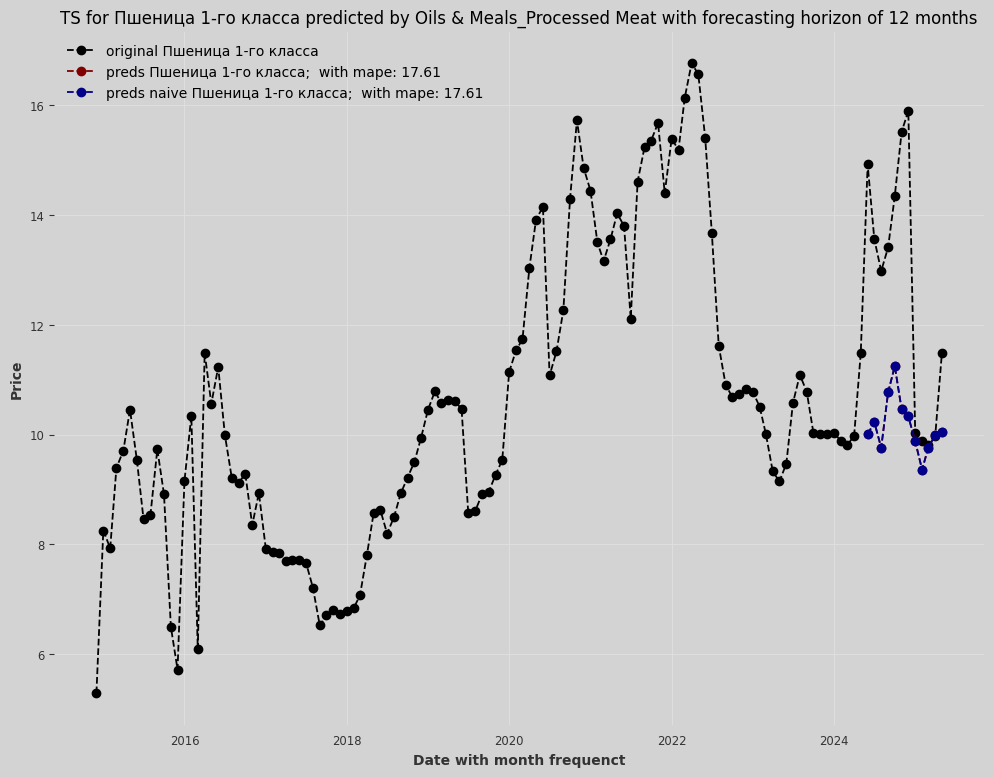

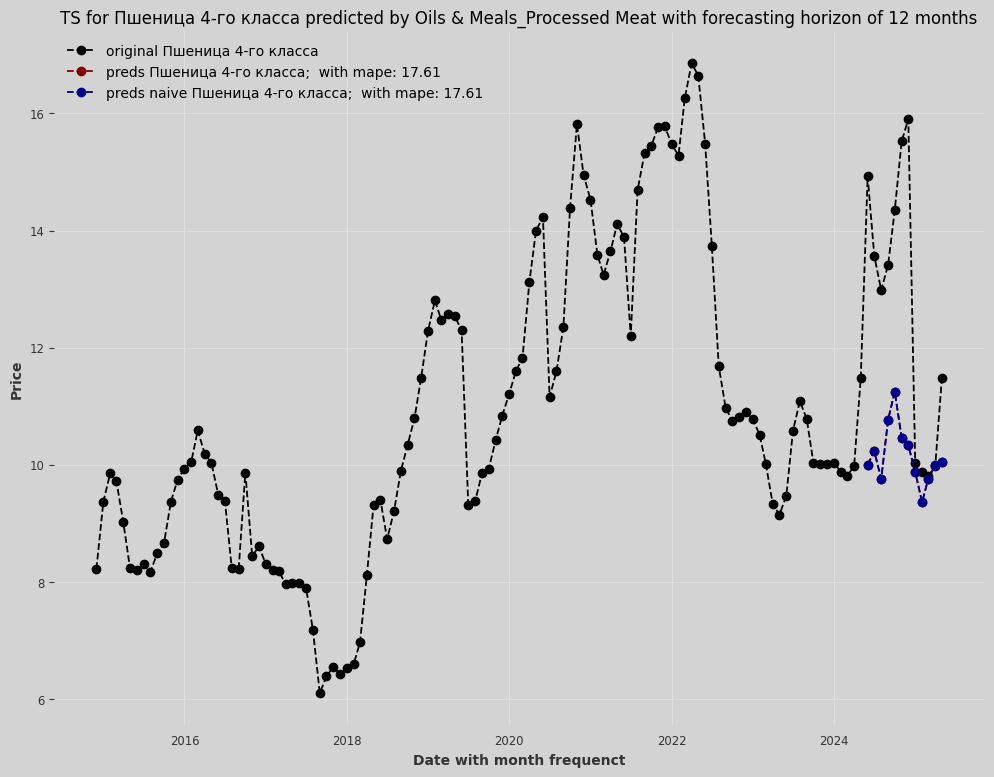

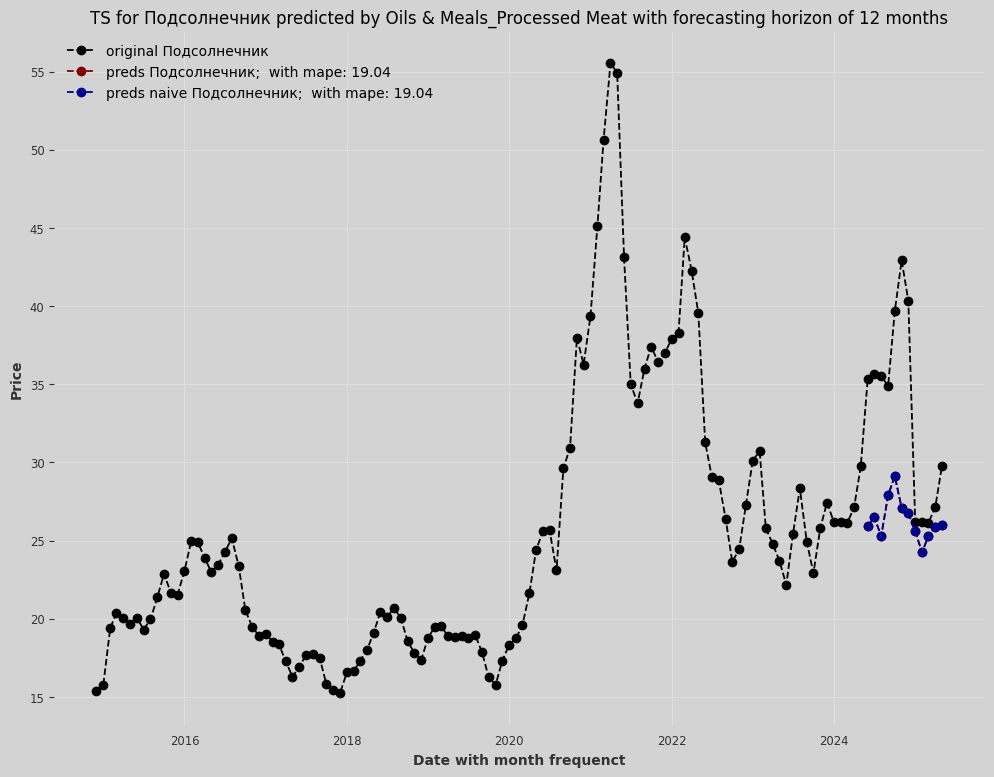

In [12]:
extrapolate_results_to_single_ts(TS_TO_PREDICT_APK,
                    apk_nona_en_rol.dropna(),
                    f"darts_result_tables_pairs_new",
                    past_idx[-1],
                    f"tft_{TS_TO_PREDICT_APK}.csv",
                    output_dir_ts=f"tft_{TS_TO_PREDICT_APK}",
                    category_map=CATEGORY_MAP,
                    best_predictors_for_idx=BEST_PREDICTORS_FOR_INDEX
                    )

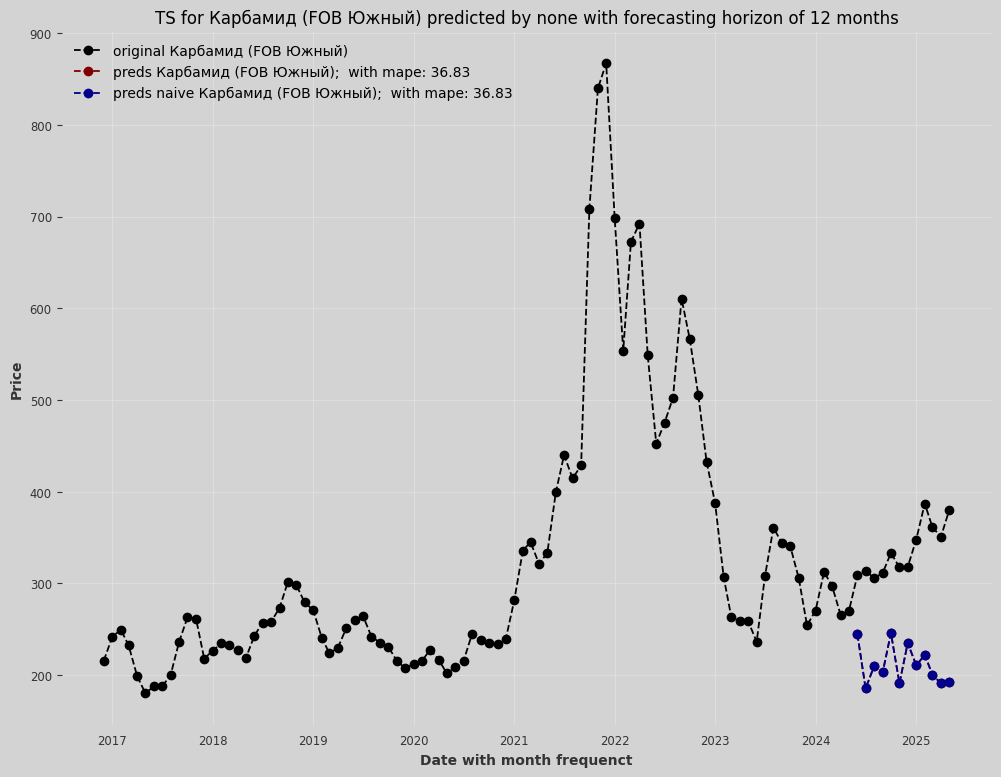

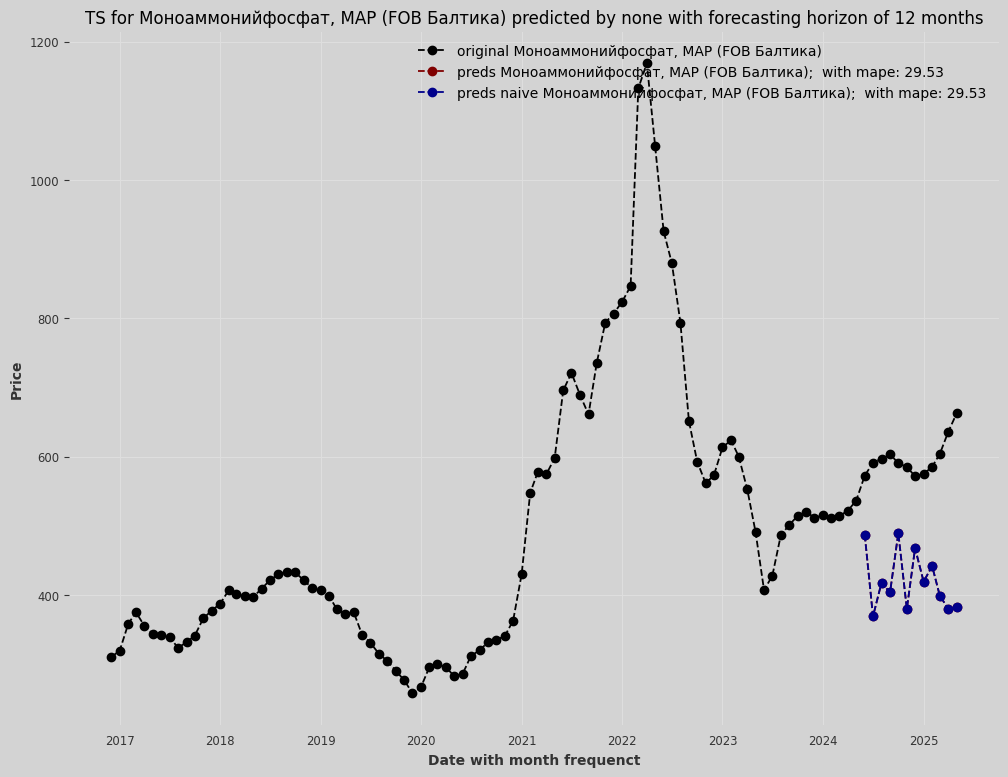

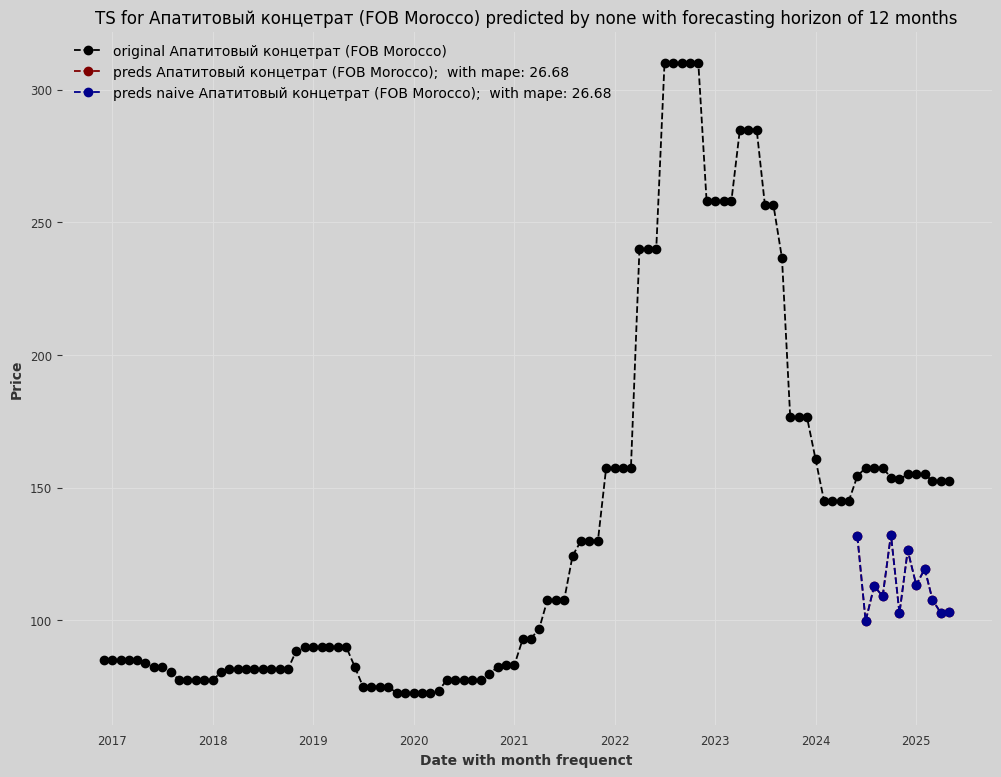

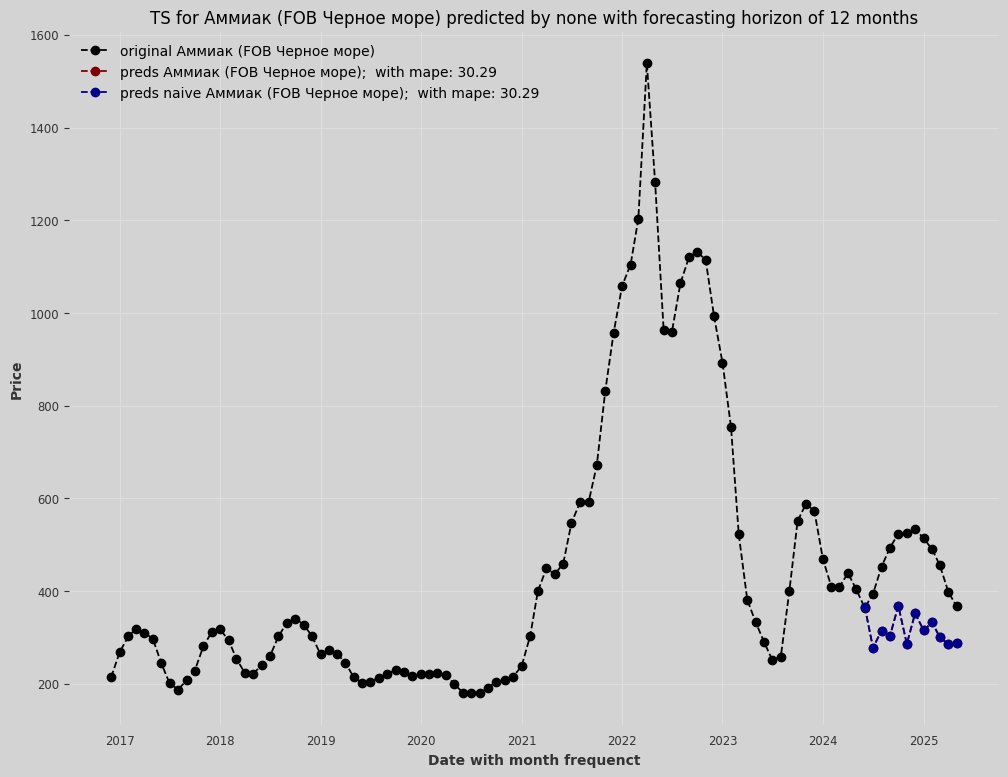

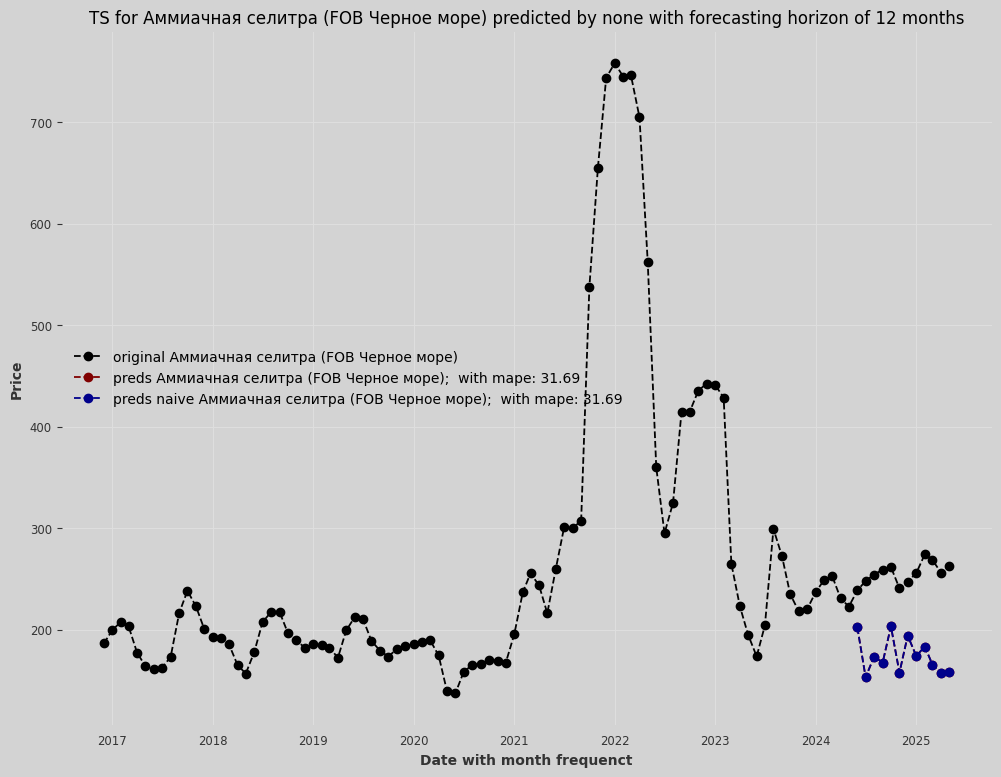

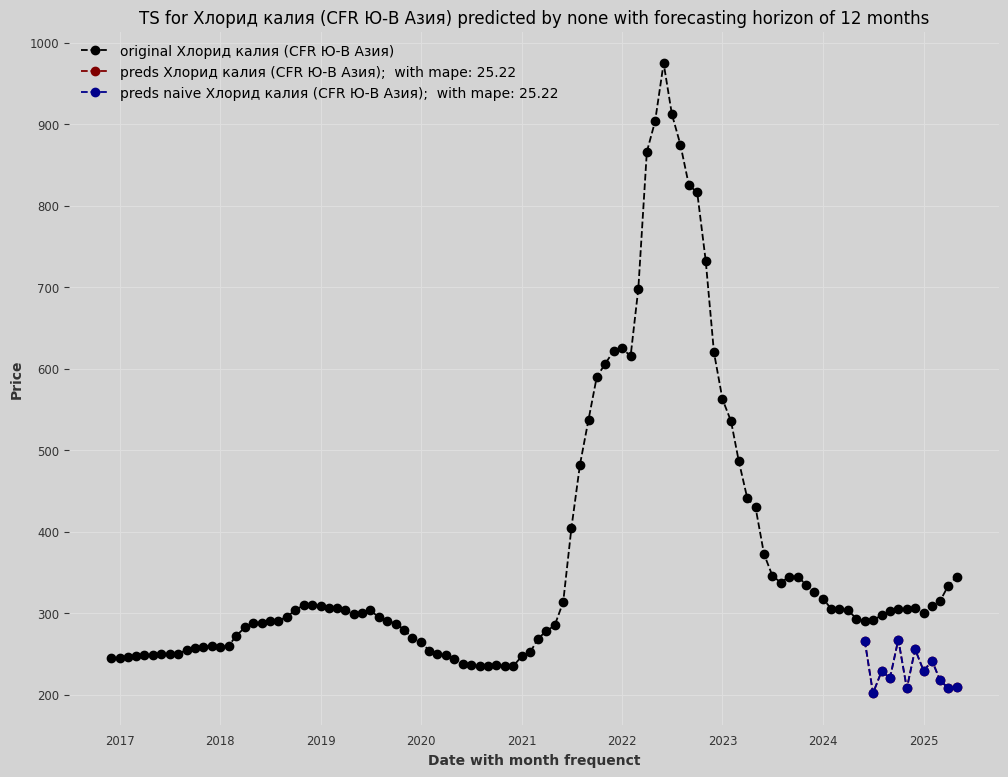

In [13]:
extrapolate_results_to_single_ts(TS_TO_PREDICT_CHEMICALS,
                    chemicals_nona_en_rol.dropna(),
                    f"darts_result_tables_pairs_new",
                    past_idx[-1],
                    f"tft_{TS_TO_PREDICT_CHEMICALS}.csv",
                    output_dir_ts=f"tft_{TS_TO_PREDICT_CHEMICALS}",
                    ts_to_cats=CATEGORY_MAP_CHEMICALS,
                    category_map=CATEGORY_MAP_CHEMICALS,
                    best_predictors_for_idx=BEST_PREDICTORS_FOR_INDEX_CHEMICALS

                    )